In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!ls /content/drive/MyDrive/casting

ls: cannot access '/content/drive/MyDrive/casting': No such file or directory


In [14]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MyDrive


In [15]:
from google.colab import files
uploaded = files.upload()          # choose best_head_only.pth
print(list(uploaded.keys()))

Saving best_head_only.pth to best_head_only.pth
['best_head_only.pth']


In [1]:
import os, glob, random, zipfile, copy
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ZIP_PATH = "/content/casting_product_image_data.zip"
EXTRACT_DIR = "/content/data"            # clean target folder

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

# Locate the folder that directly contains def_front and ok_front
data_dir = None
for root, dirs, _ in os.walk(EXTRACT_DIR):
    if "def_front" in dirs and "ok_front" in dirs:
        data_dir = root
        break

if data_dir is None:
    raise FileNotFoundError("def_front / ok_front not found. Run: !find /content/data -maxdepth 4 -type d")

print("data_dir:", data_dir)
for c in ["ok_front", "def_front"]:
    print(c, len(os.listdir(os.path.join(data_dir, c))), "images")

# Check image size (300x300 = original, 512x512 = augmented copy)
sample = glob.glob(os.path.join(data_dir, "def_front", "*.*"))[0]
print("Sample image size:", Image.open(sample).size)

Device: cuda
data_dir: /content/data/casting_data
ok_front 3000 images
def_front 3000 images
Sample image size: (300, 300)


In [2]:
CLASS_MAP = {"ok_front": 0, "def_front": 1}   # 0 = normal, 1 = defective

paths, labels = [], []
for cls, idx in CLASS_MAP.items():
    files = sorted(glob.glob(os.path.join(data_dir, cls, "*.*")))
    paths += files
    labels += [idx] * len(files)
paths, labels = np.array(paths), np.array(labels)

# Step 1: hold out 15% as the final test set (stratified)
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    paths, labels, test_size=0.15, stratify=labels, random_state=SEED
)

# Step 2: split the rest into train (70% of total) and val (15% of total)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels,
    test_size=0.15 / 0.85, stratify=trainval_labels, random_state=SEED
)

for name, y in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    print(f"{name:5s} | total {len(y):5d} | normal {np.sum(y==0):5d} | defective {np.sum(y==1):5d}")

train | total  4199 | normal  2099 | defective  2100
val   | total   901 | normal   451 | defective   450
test  | total   900 | normal   450 | defective   450


In [3]:
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),                       # impeller is round
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([                            # no augmentation
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class CastingDataset(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")    # grayscale -> 3 channels
        return self.tf(img), torch.tensor(self.labels[i], dtype=torch.float32)

BATCH = 32
train_ds = CastingDataset(train_paths, train_labels, train_tf)
val_ds   = CastingDataset(val_paths,   val_labels,   eval_tf)
test_ds  = CastingDataset(test_paths,  test_labels,  eval_tf)

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2,
                          pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(len(train_ds), len(val_ds), len(test_ds))

4199 901 900


In [4]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze the whole pretrained backbone
for p in model.parameters():
    p.requires_grad = False

# New classification head (trainable by default)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, 1)         # one logit
)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


Trainable params: 1,281 / 4,008,829


pos_weight: 0.9995238184928894
Epoch  1 | loss 0.4897 | val P 1.0000 | val R 0.5111 | val F1 0.6765
Epoch  2 | loss 0.3210 | val P 1.0000 | val R 0.6356 | val F1 0.7772
Epoch  3 | loss 0.2636 | val P 1.0000 | val R 0.6556 | val F1 0.7919
Epoch  4 | loss 0.2374 | val P 1.0000 | val R 0.6800 | val F1 0.8095
Epoch  5 | loss 0.2195 | val P 1.0000 | val R 0.6733 | val F1 0.8048
Epoch  6 | loss 0.2045 | val P 1.0000 | val R 0.7333 | val F1 0.8462
Epoch  7 | loss 0.1891 | val P 1.0000 | val R 0.8089 | val F1 0.8943
Epoch  8 | loss 0.1822 | val P 1.0000 | val R 0.7956 | val F1 0.8861
Epoch  9 | loss 0.1770 | val P 1.0000 | val R 0.7689 | val F1 0.8693
Epoch 10 | loss 0.1720 | val P 1.0000 | val R 0.7889 | val F1 0.8820
Epoch 11 | loss 0.1703 | val P 1.0000 | val R 0.8000 | val F1 0.8889
Early stopping
Best val F1: 0.8943


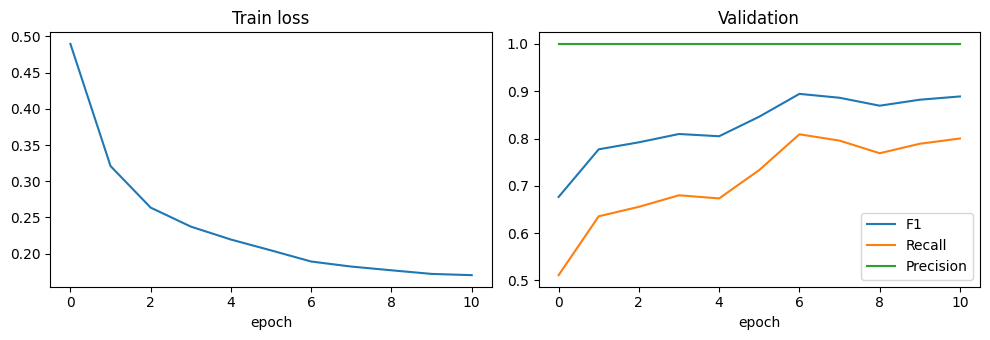

In [5]:
# pos_weight = (#negatives / #positives) up-weights the defective class
n_pos, n_neg = np.sum(train_labels == 1), np.sum(train_labels == 0)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
print("pos_weight:", pos_weight.item())
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

EPOCHS = 40
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

@torch.no_grad()
def predict_probs(loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        logits = model(x.to(device)).squeeze(1)
        probs.append(torch.sigmoid(logits).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)

best_f1, best_state, patience, bad = 0, None, 4, 0
history = {"train_loss": [], "val_f1": [], "val_recall": [], "val_precision": []}

for epoch in range(EPOCHS):
    model.train()
    model.features.eval()          # keep frozen backbone BatchNorm stats fixed
    running = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x).squeeze(1), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    val_probs, val_y = predict_probs(val_loader)
    val_pred = (val_probs >= 0.5).astype(int)
    f1 = f1_score(val_y, val_pred)
    rec = recall_score(val_y, val_pred)
    prec = precision_score(val_y, val_pred, zero_division=0)
    history["train_loss"].append(running / len(train_ds))
    history["val_f1"].append(f1)
    history["val_recall"].append(rec)
    history["val_precision"].append(prec)
    print(f"Epoch {epoch+1:2d} | loss {history['train_loss'][-1]:.4f} | "
          f"val P {prec:.4f} | val R {rec:.4f} | val F1 {f1:.4f}")

    if f1 > best_f1:
        best_f1, best_state, bad = f1, copy.deepcopy(model.state_dict()), 0
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_state)
print("Best val F1:", round(best_f1, 4))

# Training curves (useful for the README)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(history["train_loss"]); ax[0].set_title("Train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["val_f1"], label="F1")
ax[1].plot(history["val_recall"], label="Recall")
ax[1].plot(history["val_precision"], label="Precision")
ax[1].set_title("Validation"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

In [6]:
val_probs, val_y = predict_probs(val_loader)

def pick_threshold(y, p, min_recall=0.98):
    prec, rec, thr = precision_recall_curve(y, p)
    prec, rec = prec[:-1], rec[:-1]                      # align with thr
    ok = rec >= min_recall
    if ok.any():                                         # best precision with recall >= target
        i = np.argmax(np.where(ok, prec, -1))
    else:                                                # fallback: best F1
        i = np.argmax(2 * prec * rec / (prec + rec + 1e-9))
    return float(thr[i])

THRESHOLD = pick_threshold(val_y, val_probs)
print("Chosen threshold:", round(THRESHOLD, 3))

# Validation metrics at the chosen threshold
vp = (val_probs >= THRESHOLD).astype(int)
print("Val precision:", round(precision_score(val_y, vp), 4))
print("Val recall   :", round(recall_score(val_y, vp), 4))
print("Val F1       :", round(f1_score(val_y, vp), 4))

Chosen threshold: 0.064
Val precision: 0.8448
Val recall   : 0.98
Val F1       : 0.9074


              precision    recall  f1-score   support

      normal     1.0000    0.8222    0.9024       450
   defective     0.8491    1.0000    0.9184       450

    accuracy                         0.9111       900
   macro avg     0.9245    0.9111    0.9104       900
weighted avg     0.9245    0.9111    0.9104       900

Precision : 0.8491
Recall    : 1.0
F1        : 0.9184
ROC-AUC   : 0.998


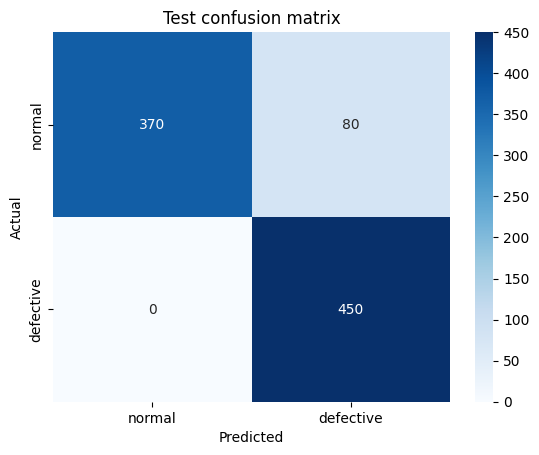

TN=370  FP (false alarms)=80  FN (missed defects)=0  TP=450


In [7]:
test_probs, test_y = predict_probs(test_loader)
test_pred = (test_probs >= THRESHOLD).astype(int)

print(classification_report(test_y, test_pred,
                            target_names=["normal", "defective"], digits=4))
print("Precision :", round(precision_score(test_y, test_pred), 4))
print("Recall    :", round(recall_score(test_y, test_pred), 4))
print("F1        :", round(f1_score(test_y, test_pred), 4))
print("ROC-AUC   :", round(roc_auc_score(test_y, test_probs), 4))

cm = confusion_matrix(test_y, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "defective"], yticklabels=["normal", "defective"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Test confusion matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP (false alarms)={fp}  FN (missed defects)={fn}  TP={tp}")

False positives: 0 | False negatives: 3
No False positives (normal predicted as defective)


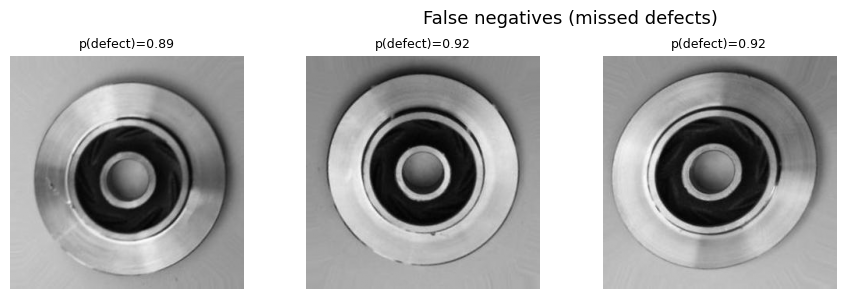

FN mean prob: 0.909


In [17]:
fp_idx = np.where((test_pred == 1) & (test_y == 0))[0]
fn_idx = np.where((test_pred == 0) & (test_y == 1))[0]
print(f"False positives: {len(fp_idx)} | False negatives: {len(fn_idx)}")

def show_errors(idx, title, max_n=12):
    idx = idx[:max_n]
    if len(idx) == 0:
        print(f"No {title}"); return
    cols = 4
    rows = int(np.ceil(len(idx) / cols))
    plt.figure(figsize=(3 * cols, 3 * rows))
    for k, i in enumerate(idx):
        plt.subplot(rows, cols, k + 1)
        plt.imshow(Image.open(test_paths[i]).convert("L"), cmap="gray")
        plt.title(f"p(defect)={test_probs[i]:.2f}", fontsize=9)
        plt.axis("off")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

show_errors(fp_idx, "False positives (normal predicted as defective)")
show_errors(fn_idx, "False negatives (missed defects)")

# Confidence of the mistakes: are they borderline or confidently wrong?
if len(fp_idx): print("FP mean prob:", test_probs[fp_idx].mean().round(3))
if len(fn_idx): print("FN mean prob:", test_probs[fn_idx].mean().round(3))

In [9]:
SAVE_DIR = "/content/drive/MyDrive/casting"
if not os.path.isdir("/content/drive"):
    SAVE_DIR = "/content/models"          # fallback if Drive is not mounted
os.makedirs(SAVE_DIR, exist_ok=True)

ckpt_path = os.path.join(SAVE_DIR, "best_head_only.pth")
torch.save({
    "model_state": model.state_dict(),
    "threshold": THRESHOLD,
    "img_size": IMG_SIZE,
    "classes": ["normal", "defective"],
}, ckpt_path)
print("Saved to", ckpt_path)

# If you used the fallback folder, download it:
# from google.colab import files; files.download(ckpt_path)

Saved to /content/models/best_head_only.pth


In [11]:
from google.colab import files
files.download(ckpt_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from sklearn.metrics import average_precision_score

# Keep the head-only results for the README comparison
cm0 = confusion_matrix(test_y, (test_probs >= THRESHOLD).astype(int))
headonly = dict(threshold=round(THRESHOLD, 4), FP=int(cm0[0, 1]), FN=int(cm0[1, 0]),
                auc=round(roc_auc_score(test_y, test_probs), 4))
headonly_state = copy.deepcopy(model.state_dict())

# Unfreeze the last 3 backbone blocks + the head
for p in model.parameters():
    p.requires_grad = False
ft_blocks = [model.features[6], model.features[7], model.features[8]]
for blk in ft_blocks:
    for p in blk.parameters():
        p.requires_grad = True
for p in model.classifier.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": [p for b in ft_blocks for p in b.parameters()], "lr": 1e-4},
    {"params": model.classifier.parameters(),                  "lr": 3e-4},
], weight_decay=1e-4)
EPOCHS_FT = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FT)

best_ap, best_state_ft, bad, patience = 0, None, 0, 4
for epoch in range(EPOCHS_FT):
    model.train()
    model.features[:6].eval()          # early blocks stay frozen, fixed BatchNorm stats
    running = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x).squeeze(1), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    vp_, vy_ = predict_probs(val_loader)
    ap = average_precision_score(vy_, vp_)
    print(f"FT epoch {epoch+1:2d} | loss {running/len(train_ds):.4f} | "
          f"val AP {ap:.4f} | val AUC {roc_auc_score(vy_, vp_):.4f}")
    if ap > best_ap:
        best_ap, best_state_ft, bad = ap, copy.deepcopy(model.state_dict()), 0
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping"); break

model.load_state_dict(best_state_ft)

# Re-tune the threshold on validation, then evaluate once on test
val_probs, val_y = predict_probs(val_loader)
THRESHOLD = pick_threshold(val_y, val_probs)
test_probs, test_y = predict_probs(test_loader)
test_pred = (test_probs >= THRESHOLD).astype(int)

print("\nNew threshold:", round(THRESHOLD, 4))
print(classification_report(test_y, test_pred, target_names=["normal", "defective"], digits=4))
cm = confusion_matrix(test_y, test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn} FP={fp} FN={fn} TP={tp} | AUC={roc_auc_score(test_y, test_probs):.4f}")
print("Head-only baseline:", headonly)

FT epoch  1 | loss 0.1172 | val AP 0.9988 | val AUC 0.9986
FT epoch  2 | loss 0.0366 | val AP 0.9988 | val AUC 0.9987
FT epoch  3 | loss 0.0322 | val AP 0.9985 | val AUC 0.9983
FT epoch  4 | loss 0.0213 | val AP 0.9995 | val AUC 0.9994
FT epoch  5 | loss 0.0171 | val AP 0.9995 | val AUC 0.9995
FT epoch  6 | loss 0.0125 | val AP 0.9996 | val AUC 0.9996
FT epoch  7 | loss 0.0153 | val AP 0.9996 | val AUC 0.9996
FT epoch  8 | loss 0.0136 | val AP 0.9997 | val AUC 0.9997
FT epoch  9 | loss 0.0118 | val AP 0.9997 | val AUC 0.9996
FT epoch 10 | loss 0.0098 | val AP 0.9996 | val AUC 0.9996
FT epoch 11 | loss 0.0142 | val AP 0.9997 | val AUC 0.9997
FT epoch 12 | loss 0.0085 | val AP 0.9996 | val AUC 0.9996
FT epoch 13 | loss 0.0115 | val AP 0.9996 | val AUC 0.9996
FT epoch 14 | loss 0.0124 | val AP 0.9996 | val AUC 0.9996
FT epoch 15 | loss 0.0099 | val AP 0.9996 | val AUC 0.9996
Early stopping

New threshold: 0.9653
              precision    recall  f1-score   support

      normal     0.993

In [18]:
SAVE_DIR = "/content/drive/MyDrive/casting" if os.path.isdir("/content/drive") else "/content/models"
os.makedirs(SAVE_DIR, exist_ok=True)
ckpt_path = os.path.join(SAVE_DIR, "best_finetuned.pth")

torch.save({
    "model_state": model.state_dict(),
    "threshold": THRESHOLD,
    "img_size": IMG_SIZE,
    "classes": ["normal", "defective"],
}, ckpt_path)
print("Saved to", ckpt_path)

# If you used /content/models, download it:
# from google.colab import files; files.download(ckpt_path)

Saved to /content/drive/MyDrive/casting/best_finetuned.pth


In [20]:
from google.colab import files
files.download(ckpt_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

recovery cell


In [ ]:
from sklearn.metrics import average_precision_score

# Loss (same as chunk 5)
n_pos, n_neg = np.sum(train_labels == 1), np.sum(train_labels == 0)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

@torch.no_grad()
def predict_probs(loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        logits = model(x.to(device)).squeeze(1)
        probs.append(torch.sigmoid(logits).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)

def pick_threshold(y, p, min_recall=0.98):
    prec, rec, thr = precision_recall_curve(y, p)
    prec, rec = prec[:-1], rec[:-1]
    ok = rec >= min_recall
    if ok.any():
        i = np.argmax(np.where(ok, prec, -1))
    else:
        i = np.argmax(2 * prec * rec / (prec + rec + 1e-9))
    return float(thr[i])

# Load the saved head-only weights
ckpt = torch.load("/content/drive/MyDrive/casting/best_head_only.pth",
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
THRESHOLD = ckpt["threshold"]

# Baseline numbers that chunk 10 expects
test_probs, test_y = predict_probs(test_loader)
print("Loaded threshold:", round(THRESHOLD, 4))
cm0 = confusion_matrix(test_y, (test_probs >= THRESHOLD).astype(int))
print(cm0)    # should match your earlier result: TN=370 FP=80 FN=0 TP=450